In [716]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pickle

In [717]:
df = pd.read_csv("sensor.csv")

In [718]:
print("Original shape:", df.shape)
print(df.head())

Original shape: (27150, 15)
   Unnamed: 0  session_id          run_type scenario  time_ms  sensor_id  \
0           0           1  C_front_far_deep     safe      285          1   
1           1           1  C_front_far_deep     safe      564          1   
2           2           1  C_front_far_deep     safe      839          1   
3           3           1  C_front_far_deep     safe     1114          1   
4           4           1  C_front_far_deep     safe     1408          1   

   echo_us  valid  dist_cm  dist_f_cm  baseline_cm  enter_thr_cm  exit_thr_cm  \
0     3619      1    267.8      267.8          0.0           0.0          0.0   
1     3601      1    266.5      267.5          0.0           0.0          0.0   
2     3605      1    266.8      267.3          0.0           0.0          0.0   
3        0      0      0.0      267.3          0.0           0.0          0.0   
4     3613      1    267.4      267.3          0.0           0.0          0.0   

   danger  event  
0     0.0

In [719]:
# keep only valid readings
df = df[df["valid"] == 1].copy()

In [720]:
# remove rows before baseline is learned
df = df[df["baseline_cm"] > 0].copy()

In [721]:
# remove impossible distances if any slipped in
df = df[(df["dist_f_cm"] > 20) & (df["dist_f_cm"] <= 600)].copy()

In [722]:
print("After cleaning:", df.shape)

After cleaning: (23014, 15)


In [723]:
# =========================
# 4. FEATURE ENGINEERING
# =========================

In [724]:
# main distance difference from baseline
df["delta"] = df["dist_f_cm"] - df["baseline_cm"]

In [725]:
df.head()

,Unnamed: 0,session_id,run_type,scenario,time_ms,sensor_id,echo_us,valid,dist_cm,dist_f_cm,baseline_cm,enter_thr_cm,exit_thr_cm,danger,event,delta
37,112,1,C_front_far_deep,safe,31798,1,3646,1,269.8,267.5,268.3,120.0,140.0,0.0,0,-0.8
38,113,1,C_front_far_deep,safe,32080,1,3629,1,268.5,267.8,268.3,208.3,228.3,0.0,0,-0.5
39,114,1,C_front_far_deep,safe,32363,1,3657,1,270.6,268.5,268.3,208.3,228.3,0.0,0,0.2
40,115,1,C_front_far_deep,safe,32632,1,3659,1,270.8,269.1,268.3,208.3,228.3,0.0,0,0.8
41,116,1,C_front_far_deep,safe,32902,1,3627,1,268.4,268.9,268.3,208.3,228.3,0.0,0,0.6


In [726]:
# first row contains a hardcoded enter and exit thresholds. must remove them
#df = df[df["delta"] != 0].copy()

In [727]:
#df.head()

In [728]:
# # main distance difference from baseline
# df["delta"] = df["dist_f_cm"] - df["baseline_cm"]

In [729]:
# # normalized delta (helps when baseline changes across sessions/sensors)
# df["delta_norm"] = df["delta"] / df["baseline_cm"]

In [730]:
# distance to thresholds
df["dist_to_enter"] = df["dist_f_cm"] - df["enter_thr_cm"]
df["dist_to_exit"] = df["dist_f_cm"] - df["exit_thr_cm"]

In [731]:
group_cols = []
if "session_id" in df.columns:
    group_cols.append("session_id")

In [732]:
group_cols

['session_id']

In [733]:
df["time_gap"] =df.groupby(group_cols)["time_ms"].diff()

In [734]:
df.shape

(23014, 19)

In [735]:
#drop rows with NaN time_gap (first row of each session)
df = df.dropna(subset=["time_gap"])

In [736]:
df.head()

,Unnamed: 0,session_id,run_type,scenario,time_ms,sensor_id,echo_us,valid,dist_cm,dist_f_cm,baseline_cm,enter_thr_cm,exit_thr_cm,danger,event,delta,dist_to_enter,dist_to_exit,time_gap
38,113,1,C_front_far_deep,safe,32080,1,3629,1,268.5,267.8,268.3,208.3,228.3,0.0,0,-0.5,59.5,39.5,282.0
39,114,1,C_front_far_deep,safe,32363,1,3657,1,270.6,268.5,268.3,208.3,228.3,0.0,0,0.2,60.2,40.2,283.0
40,115,1,C_front_far_deep,safe,32632,1,3659,1,270.8,269.1,268.3,208.3,228.3,0.0,0,0.8,60.8,40.8,269.0
41,116,1,C_front_far_deep,safe,32902,1,3627,1,268.4,268.9,268.3,208.3,228.3,0.0,0,0.6,60.6,40.6,270.0
42,117,1,C_front_far_deep,safe,33190,1,3656,1,270.5,269.3,268.3,208.3,228.3,0.0,0,1.0,61.0,41.0,288.0


In [737]:
df["velocity"] = df.groupby(group_cols)["dist_f_cm"].diff()/df["time_gap"]
df["acceleration"] = df.groupby(group_cols)["velocity"].diff()/df["time_gap"]

In [738]:
df.head()

,Unnamed: 0,session_id,run_type,scenario,time_ms,sensor_id,echo_us,valid,dist_cm,dist_f_cm,...,enter_thr_cm,exit_thr_cm,danger,event,delta,dist_to_enter,dist_to_exit,time_gap,velocity,acceleration
38,113,1,C_front_far_deep,safe,32080,1,3629,1,268.5,267.8,...,208.3,228.3,0.0,0,-0.5,59.5,39.5,282.0,NaN,NaN
39,114,1,C_front_far_deep,safe,32363,1,3657,1,270.6,268.5,...,208.3,228.3,0.0,0,0.2,60.2,40.2,283.0,0.002473,NaN
40,115,1,C_front_far_deep,safe,32632,1,3659,1,270.8,269.1,...,208.3,228.3,0.0,0,0.8,60.8,40.8,269.0,0.002230,-9.034013e-07
41,116,1,C_front_far_deep,safe,32902,1,3627,1,268.4,268.9,...,208.3,228.3,0.0,0,0.6,60.6,40.6,270.0,-0.000741,-1.100453e-05
42,117,1,C_front_far_deep,safe,33190,1,3656,1,270.5,269.3,...,208.3,228.3,0.0,0,1.0,61.0,41.0,288.0,0.001389,7.394547e-06


In [739]:
# drop rows with NaN velocity or acceleration (first 2 rows of each session)
df = df.dropna(subset=["velocity", "acceleration"])

In [740]:
print("\nAfter NaN handling:", df.shape)


After NaN handling: (22744, 21)


In [741]:
df.head()

,Unnamed: 0,session_id,run_type,scenario,time_ms,sensor_id,echo_us,valid,dist_cm,dist_f_cm,...,enter_thr_cm,exit_thr_cm,danger,event,delta,dist_to_enter,dist_to_exit,time_gap,velocity,acceleration
40,115,1,C_front_far_deep,safe,32632,1,3659,1,270.8,269.1,...,208.3,228.3,0.0,0,0.8,60.8,40.8,269.0,0.002230,-9.034013e-07
41,116,1,C_front_far_deep,safe,32902,1,3627,1,268.4,268.9,...,208.3,228.3,0.0,0,0.6,60.6,40.6,270.0,-0.000741,-1.100453e-05
42,117,1,C_front_far_deep,safe,33190,1,3656,1,270.5,269.3,...,208.3,228.3,0.0,0,1.0,61.0,41.0,288.0,0.001389,7.394547e-06
43,118,1,C_front_far_deep,safe,33476,1,3667,1,271.4,269.8,...,208.3,228.3,0.0,0,1.5,61.5,41.5,286.0,0.001748,1.256513e-06
44,119,1,C_front_far_deep,safe,33759,1,3679,1,272.2,270.4,...,208.3,228.3,0.0,0,2.1,62.1,42.1,283.0,0.002120,1.314098e-06


In [742]:
feature_cols = [
    "time_gap",
    "dist_f_cm",
    "delta",
    "velocity",
    "acceleration"
]


In [743]:
if "state" not in df.columns:
    df["state"] = (df["danger"] > 0).astype(int)
    label_col = "state"

In [744]:
print("\nUsing features:", feature_cols)
print("Using label:", label_col)


Using features: ['time_gap', 'dist_f_cm', 'delta', 'velocity', 'acceleration']
Using label: state


In [745]:
df.head(1000)

,Unnamed: 0,session_id,run_type,scenario,time_ms,sensor_id,echo_us,valid,dist_cm,dist_f_cm,...,exit_thr_cm,danger,event,delta,dist_to_enter,dist_to_exit,time_gap,velocity,acceleration,state
40,115,1,C_front_far_deep,safe,32632,1,3659,1,270.8,269.1,...,228.3,0.000,0,0.8,60.8,40.8,269.0,0.002230,-9.034013e-07,0
41,116,1,C_front_far_deep,safe,32902,1,3627,1,268.4,268.9,...,228.3,0.000,0,0.6,60.6,40.6,270.0,-0.000741,-1.100453e-05,0
42,117,1,C_front_far_deep,safe,33190,1,3656,1,270.5,269.3,...,228.3,0.000,0,1.0,61.0,41.0,288.0,0.001389,7.394547e-06,0
43,118,1,C_front_far_deep,safe,33476,1,3667,1,271.4,269.8,...,228.3,0.000,0,1.5,61.5,41.5,286.0,0.001748,1.256513e-06,0
44,119,1,C_front_far_deep,safe,33759,1,3679,1,272.2,270.4,...,228.3,0.000,0,2.1,62.1,42.1,283.0,0.002120,1.314098e-06,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,4720,4,C_front_far_deep,approach_danger,1328628,1,2986,1,221.0,196.9,...,225.9,1.000,0,-69.0,-9.0,-29.0,280.0,0.028929,2.989671e-05,1
1196,4721,4,C_front_far_deep,approach_danger,1328923,1,3077,1,227.7,204.6,...,225.9,1.000,0,-61.3,-1.3,-21.3,295.0,0.026102,-9.582632e-06,1
1197,4722,4,C_front_far_deep,approach_danger,1329195,1,3233,1,239.2,213.2,...,225.9,0.939,0,-52.7,7.3,-12.7,272.0,0.031618,2.027924e-05,1
1198,4723,4,C_front_far_deep,approach_danger,1329474,1,3372,1,249.5,222.3,...,225.9,0.863,0,-43.6,16.4,-3.6,279.0,0.032616,3.580073e-06,1


In [746]:
# # =========================
# # 7. NORMALIZE FEATURES
# # =========================
# # z-score normalization
# feature_means = df[feature_cols].mean()
# feature_stds = df[feature_cols].std().replace(0, 1)

# df_norm = df.copy()
# df_norm[feature_cols] = (df[feature_cols] - feature_means) / feature_stds

# print("\nNormalized sample:")
# print(df_norm[feature_cols].head())

In [747]:
# df_norm.head()

In [748]:
print(group_cols)

['session_id']


In [749]:
# =========================
# 8. BUILD TIME WINDOWS
# =========================
WINDOW_SIZE = 15
STEP_SIZE = 5

PRED_HORIZON = 5

X = []
y = []

# keep windows separated by session and sensor
grouped = df.groupby(group_cols)

In [750]:
for group_key, group in grouped:

    group = group.sort_values("time_ms").reset_index(drop=True)

    if len(group) < WINDOW_SIZE + PRED_HORIZON:
        continue

    for start in range(0, len(group) - WINDOW_SIZE - PRED_HORIZON + 1, STEP_SIZE):
            
        end = start + WINDOW_SIZE
        label_index = end - 1 + PRED_HORIZON

        window_features = group.iloc[start:end][feature_cols].values
        window_label = group.iloc[label_index][label_col]

        X.append(window_features)
        y.append(window_label)
        
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4241, 15, 5)
y shape: (4241,)


In [751]:
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print("\nWindowed dataset shapes:")
print("X shape:", X.shape)   # (samples, time_steps, features)
print("y shape:", y.shape)


Windowed dataset shapes:
X shape: (4241, 15, 5)
y shape: (4241,)


In [752]:
# # =========================
# # 9. SAVE OUTPUTS
# # =========================
# # cleaned flat table
# df.to_csv("sensor_preprocessed_flat.csv", index=False)

# # normalized flat table
# df_norm.to_csv("sensor_preprocessed_normalized.csv", index=False)

# # SNN-ready arrays
# np.save("X_snn.npy", X)
# np.save("y_snn.npy", y)

# print("\nSaved files:")
# print("sensor_preprocessed_flat.csv")
# print("sensor_preprocessed_normalized.csv")
# print("X_snn.npy")
# print("y_snn.npy")

In [753]:
print(X[50].shape)
print(X[50])
print("Label:", y[100])

(15, 5)
[[ 2.9000000e+02  2.3670000e+02 -1.4500000e+01  3.1034483e-03
  -3.1666350e-05]
 [ 2.7900000e+02  2.3689999e+02 -1.4300000e+01  7.1684585e-04
  -8.5541305e-06]
 [ 2.6800000e+02  2.3560001e+02 -1.5600000e+01 -4.8507461e-03
  -2.0774598e-05]
 [ 2.8800000e+02  2.3339999e+02 -1.7799999e+01 -7.6388889e-03
  -9.6810509e-06]
 [ 2.7400000e+02  2.3139999e+02 -1.9799999e+01 -7.2992700e-03
   1.2394847e-06]
 [ 2.7700000e+02  2.2920000e+02 -2.2000000e+01 -7.9422379e-03
  -2.3211849e-06]
 [ 2.7600000e+02  2.2689999e+02 -2.4299999e+01 -8.3333338e-03
  -1.4170112e-06]
 [ 2.6900000e+02  2.2600000e+02 -2.5200001e+01 -3.3457249e-03
   1.8541296e-05]
 [ 2.8500000e+02  2.2500000e+02 -2.6200001e+01 -3.5087720e-03
  -5.7209479e-07]
 [ 2.8700000e+02  2.2420000e+02 -2.7000000e+01 -2.7874564e-03
   2.5132945e-06]
 [ 2.8100000e+02  2.2339999e+02 -2.7799999e+01 -2.8469751e-03
  -2.1181012e-07]
 [ 2.8600000e+02  2.2389999e+02 -2.7299999e+01  1.7482517e-03
   1.6067226e-05]
 [ 2.8900000e+02  2.2380000e+02 

In [754]:
unique, counts = np.unique(y, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(3431), np.int64(1): np.int64(810)}


In [755]:
# total number of windows
n = len(X)

# 70% train, 15% validation, 15% test
train_end = int(0.70 * n)
val_end = int(0.85 * n)

X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

print("Train:", X_train.shape, y_train.shape)
print("Val  :", X_val.shape, y_val.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (2968, 15, 5) (2968,)
Val  : (636, 15, 5) (636,)
Test : (637, 15, 5) (637,)


In [756]:
def label_counts(name, labels):
    unique, counts = np.unique(labels, return_counts=True)
    print(name, dict(zip(unique, counts)))

label_counts("Train", y_train)
label_counts("Val", y_val)
label_counts("Test", y_test)

Train {np.int64(0): np.int64(2405), np.int64(1): np.int64(563)}
Val {np.int64(0): np.int64(507), np.int64(1): np.int64(129)}
Test {np.int64(0): np.int64(519), np.int64(1): np.int64(118)}


In [757]:
# Save original shapes
n_train, t_train, f_train = X_train.shape
n_val, t_val, f_val = X_val.shape
n_test, t_test, f_test = X_test.shape

In [758]:
# Reshape 3D -> 2D
X_train_2d = X_train.reshape(-1, f_train)
X_val_2d = X_val.reshape(-1, f_val)
X_test_2d = X_test.reshape(-1, f_test)

In [759]:
from sklearn.preprocessing import StandardScaler
# Fit scaler ONLY on training data
scaler = StandardScaler()
X_train_scaled_2d = scaler.fit_transform(X_train_2d)

In [760]:
# Apply same scaler to val/test
X_val_scaled_2d = scaler.transform(X_val_2d)
X_test_scaled_2d = scaler.transform(X_test_2d)

In [761]:
# Reshape back 2D -> 3D
X_train_scaled = X_train_scaled_2d.reshape(n_train, t_train, f_train)
X_val_scaled = X_val_scaled_2d.reshape(n_val, t_val, f_val)
X_test_scaled = X_test_scaled_2d.reshape(n_test, t_test, f_test)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled val shape  :", X_val_scaled.shape)
print("Scaled test shape :", X_test_scaled.shape)

Scaled train shape: (2968, 15, 5)
Scaled val shape  : (636, 15, 5)
Scaled test shape : (637, 15, 5)


In [762]:
# X_train_scaled = X_train
# X_val_scaled = X_val
# X_test_scaled = X_test

In [763]:
print("Before scaling:")
print(X_train[1])

print("\nAfter scaling:")
print(X_train_scaled[1])

Before scaling:
[[ 2.9000000e+02  2.7110001e+02  2.8000000e+00  2.4137930e-03
   1.0125923e-06]
 [ 2.9000000e+02  2.7220001e+02  3.9000001e+00  3.7931034e-03
   4.7562426e-06]
 [ 2.8200000e+02  2.7250000e+02  4.1999998e+00  1.0638298e-03
  -9.6782751e-06]
 [ 2.8500000e+02  2.7250000e+02  4.1999998e+00  0.0000000e+00
  -3.7327361e-06]
 [ 2.8300000e+02  2.7239999e+02  4.0999999e+00 -3.5335688e-04
  -1.2486109e-06]
 [ 2.1415000e+04  2.7079999e+02  2.5000000e+00 -7.4713986e-05
   1.3011576e-08]
 [ 2.8900000e+02  2.7000000e+02  1.7000000e+00 -2.7681661e-03
  -9.3199033e-06]
 [ 2.9200000e+02  2.7010001e+02  1.8000000e+00  3.4246576e-04
   1.0652849e-05]
 [ 2.9400000e+02  2.7000000e+02  1.7000000e+00 -3.4013606e-04
  -2.3217749e-06]
 [ 2.7600000e+02  2.6979999e+02  1.5000000e+00 -7.2463771e-04
  -1.3931218e-06]
 [ 2.7400000e+02  2.6950000e+02  1.2000000e+00 -1.0948905e-03
  -1.3512877e-06]
 [ 2.7500000e+02  2.6889999e+02  6.0000002e-01 -2.1818182e-03
  -3.9524643e-06]
 [ 2.8600000e+02  2.6889

In [764]:
!pip install torch torchvision torchaudio

In [765]:
import torch

In [766]:
X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)

X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

X_test_t = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

print(X_train_t.shape, y_train_t.shape)

torch.Size([2968, 15, 5]) torch.Size([2968])


In [767]:
#Create DataLoaders
from torch.utils.data import TensorDataset, DataLoader

batch_size = 64

train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, y_test_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [768]:
#Handle Class Imbalance
#penalize mistakes on danger more strongly

In [769]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32)

print(class_weights)

tensor([0.6170, 2.6359])


In [770]:
#Loss function with class weights
import torch.nn as nn

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [771]:
!pip install snntorch

In [772]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import snntorch as snn
from snntorch import surrogate
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [773]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [774]:
class_weights = class_weights.to(device)

In [775]:
#the SNN model
class SimpleSNN(nn.Module):
    def __init__(self, input_size=5, hidden_size=32, output_size=2, beta=0.9):
        super().__init__()

        # Fully connected layers
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, output_size)

        # Surrogate gradient for backpropagation through spikes
        spike_grad = surrogate.fast_sigmoid()

        # LIF neurons
        self.lif1 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.lif2 = snn.Leaky(beta=beta, spike_grad=spike_grad)
        self.lif3 = snn.Leaky(beta=beta, spike_grad=spike_grad)

    def forward(self, x):
        batch_size = x.size(0)
        time_steps = x.size(1)

        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()

        mem3_rec = []

        for t in range(time_steps):
            cur1 = self.fc1(x[:, t, :])
            spk1, mem1 = self.lif1(cur1, mem1)

            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)

            cur3 = self.fc3(spk2)
            spk3, mem3 = self.lif3(cur3, mem3)

            mem3_rec.append(mem3)

        mem3_rec = torch.stack(mem3_rec, dim=0)   # (time_steps, batch, output_size)
        return mem3_rec



In [776]:
#Create the model
model = SimpleSNN(input_size=5, hidden_size=32, output_size=2, beta=0.9).to(device)
print(model)

SimpleSNN(
  (fc1): Linear(in_features=5, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=2, bias=True)
  (lif1): Leaky()
  (lif2): Leaky()
  (lif3): Leaky()
)


In [777]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [778]:
#Training loop
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        mem_rec = model(X_batch)          # shape: (time_steps, batch, 2)
        output = mem_rec[-1]              # last time step -> (batch, 2)

        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        preds = torch.argmax(output, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc

In [779]:
# Validation loop
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            mem_rec = model(X_batch)
            output = mem_rec[-1]

            loss = criterion(output, y_batch)
            running_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(output, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_labels, all_preds

In [780]:
num_epochs = 20

train_losses = []
val_losses = []
train_accs = []
val_accs = []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

Epoch [1/20] Train Loss: 0.4880 | Train Acc: 0.8386 | Val Loss: 0.3504 | Val Acc: 0.9119
Epoch [2/20] Train Loss: 0.2347 | Train Acc: 0.9340 | Val Loss: 0.2343 | Val Acc: 0.9324
Epoch [3/20] Train Loss: 0.1719 | Train Acc: 0.9390 | Val Loss: 0.2330 | Val Acc: 0.9277
Epoch [4/20] Train Loss: 0.1591 | Train Acc: 0.9491 | Val Loss: 0.2069 | Val Acc: 0.9355
Epoch [5/20] Train Loss: 0.1447 | Train Acc: 0.9468 | Val Loss: 0.2050 | Val Acc: 0.9198
Epoch [6/20] Train Loss: 0.1344 | Train Acc: 0.9538 | Val Loss: 0.1845 | Val Acc: 0.9355
Epoch [7/20] Train Loss: 0.1262 | Train Acc: 0.9545 | Val Loss: 0.1762 | Val Acc: 0.9513
Epoch [8/20] Train Loss: 0.1225 | Train Acc: 0.9552 | Val Loss: 0.1770 | Val Acc: 0.9403
Epoch [9/20] Train Loss: 0.1135 | Train Acc: 0.9650 | Val Loss: 0.1899 | Val Acc: 0.9607
Epoch [10/20] Train Loss: 0.1247 | Train Acc: 0.9609 | Val Loss: 0.1589 | Val Acc: 0.9465
Epoch [11/20] Train Loss: 0.1069 | Train Acc: 0.9636 | Val Loss: 0.1924 | Val Acc: 0.9528
Epoch [12/20] Train

In [781]:
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc : {test_acc:.4f}")

Test Loss: 0.1452
Test Acc : 0.9623


In [782]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["Safe", "Danger"]))

              precision    recall  f1-score   support

        Safe       0.99      0.96      0.98       519
      Danger       0.86      0.96      0.90       118

    accuracy                           0.96       637
   macro avg       0.92      0.96      0.94       637
weighted avg       0.97      0.96      0.96       637



In [783]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(cm)

[[500  19]
 [  5 113]]


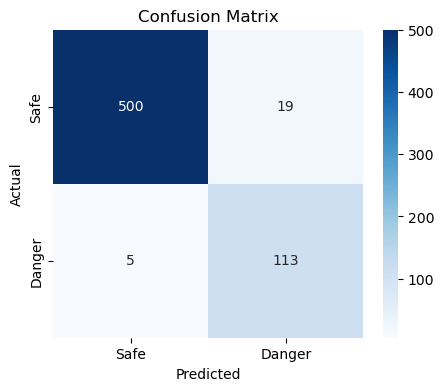

In [784]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Safe","Danger"],
            yticklabels=["Safe","Danger"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

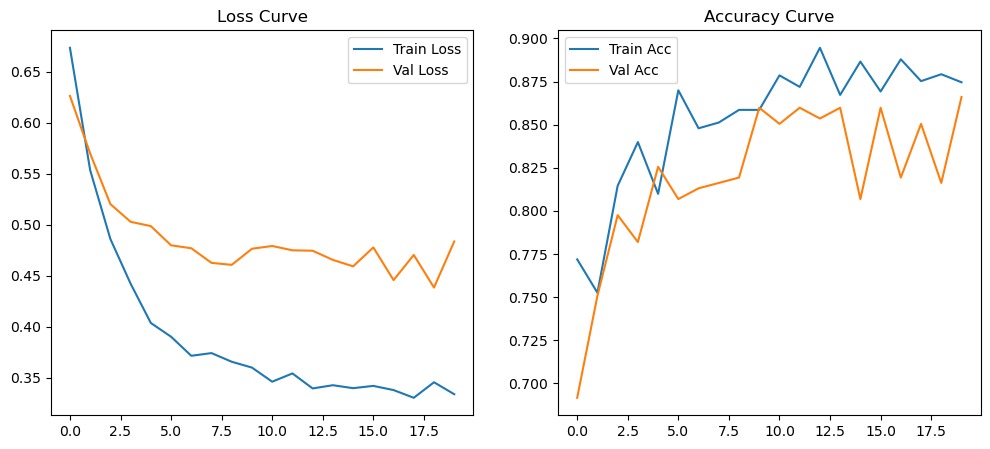

In [370]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_losses,label="Train Loss")
plt.plot(val_losses,label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs,label="Train Acc")
plt.plot(val_accs,label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")

plt.show()